### Conhecendo os dados

In [1]:
import pandas as pd

In [2]:
dados = pd.read_csv("C:/Users/augus/OneDrive/Documentos/Data Science/Regressão linear - Transformando variavies/precos_casas.csv")

In [3]:
dados

,valor,area_primeiro_andar,existe_segundo_andar,area_quintal,dist_metro,dist_parque
0,1042500,79.52,1,23.86,1.639,3.039
1,907500,117.24,0,35.17,1.538,10.910
2,1117500,85.47,1,25.64,1.275,11.791
3,700000,89.28,1,21.07,1.223,10.877
4,1250000,106.37,1,31.91,0.868,11.247
...,...,...,...,...,...,...
1455,875000,88.54,1,26.56,2.984,12.175
1456,1050000,192.59,0,42.98,2.315,2.608
1457,1332500,110.37,1,32.11,1.253,13.424
1458,710625,100.15,0,30.04,4.507,1.087


In [4]:
dados.shape

(1460, 6)

In [5]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   valor                 1460 non-null   int64  
 1   area_primeiro_andar   1460 non-null   float64
 2   existe_segundo_andar  1460 non-null   int64  
 3   area_quintal          1460 non-null   float64
 4   dist_metro            1460 non-null   float64
 5   dist_parque           1460 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 68.6 KB


### Entendo a correlaçao

###### Correlação entre dados é uma medida que indica o quanto duas variáveis se relacionam entre si e em qual direção.

Tipos de correlação
Correlação positiva

Quando uma aumenta, a outra também tende a aumentar.

Exemplo: altura e peso de pessoas (em média, pessoas mais altas pesam mais).

Correlação negativa

Quando uma aumenta, a outra tende a diminuir.

Exemplo: velocidade de um carro e tempo para chegar ao destino (mais velocidade → menos tempo).

Correlação zero (ou muito próxima de zero)

Não há relação aparente.

Exemplo: número de pets que você tem e a quantidade de planetas no sistema solar (nenhuma ligação lógica).

In [6]:
corr = dados.corr().round(3)
corr

,valor,area_primeiro_andar,existe_segundo_andar,area_quintal,dist_metro,dist_parque
valor,1.000,0.606,0.138,0.614,-0.644,-0.071
area_primeiro_andar,0.606,1.000,-0.339,0.820,-0.369,-0.058
existe_segundo_andar,0.138,-0.339,1.000,-0.301,-0.191,-0.007
area_quintal,0.614,0.820,-0.301,1.000,-0.440,-0.058
dist_metro,-0.644,-0.369,-0.191,-0.440,1.000,0.089
dist_parque,-0.071,-0.058,-0.007,-0.058,0.089,1.000


In [7]:
corr['valor'].to_frame()

,valor
valor,1.000
area_primeiro_andar,0.606
existe_segundo_andar,0.138
area_quintal,0.614
dist_metro,-0.644
dist_parque,-0.071


### Visualizando uma Regressão Linear com uma variável independente

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

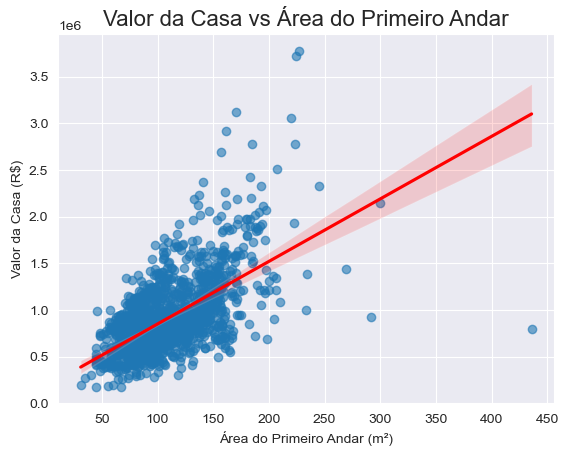

In [9]:
sns.set_style('darkgrid')
sns.regplot(x='area_primeiro_andar', y='valor', data = dados, line_kws={'color': 'red'}, scatter_kws={"alpha": 0.6})
plt.title("Valor da Casa vs Área do Primeiro Andar", fontsize=16)
plt.xlabel("Área do Primeiro Andar (m²)")
plt.ylabel("Valor da Casa (R$)")
plt.show()

### Visualizando o comportamento da variável dependente

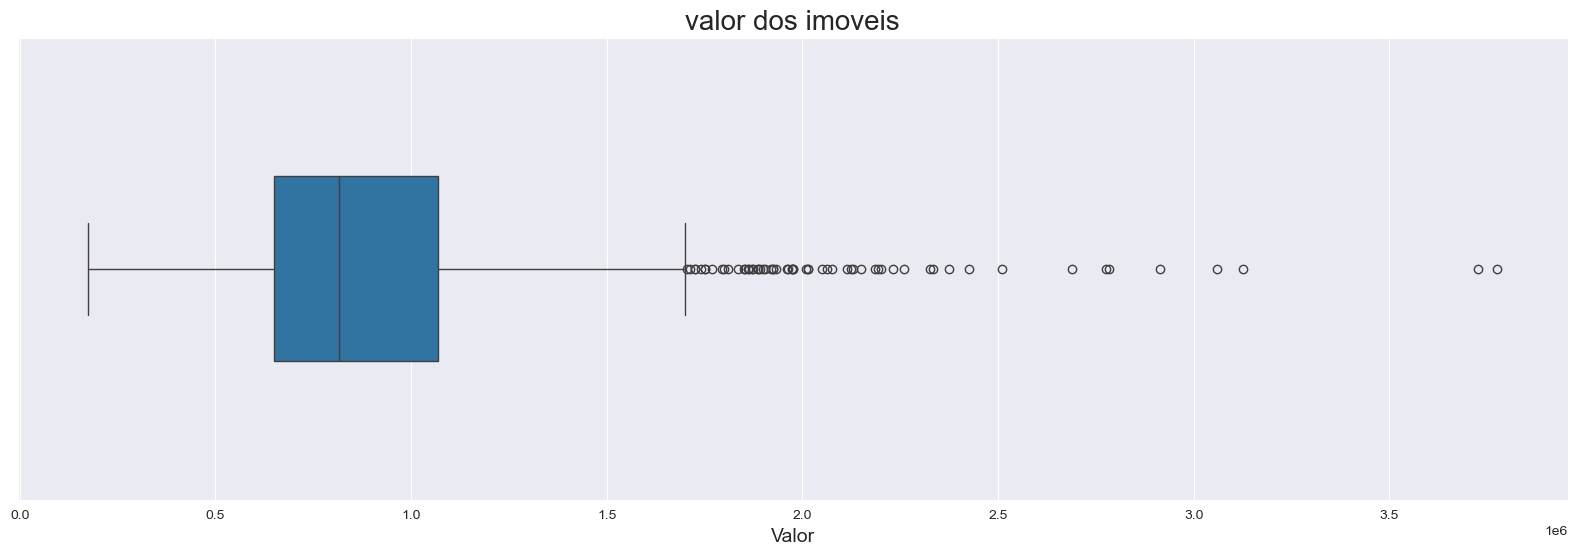

In [10]:
ax = sns.boxplot(x='valor', data=dados, width=0.4)
ax.figure.set_size_inches(20,6)
ax.set_title('valor dos imoveis', fontsize=20)
ax.set_xlabel('Valor', fontsize=14)
plt.show()

### Investigando a distribuição de frequência da variável dependente

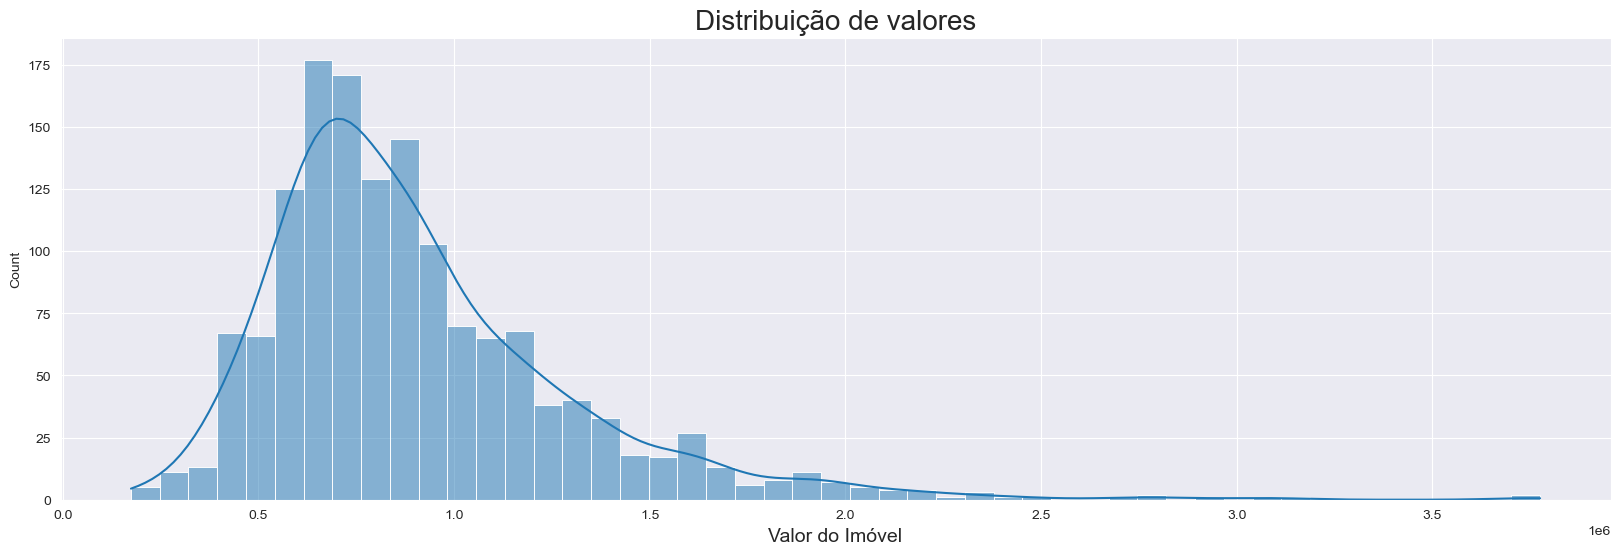

In [11]:
ax = sns.histplot(data=dados, x='valor', kde=True)
ax.figure.set_size_inches(20,6)
ax.set_title('Distribuição de valores', fontsize=20)
ax.set_xlabel('Valor do Imóvel', fontsize=14)
plt.show()

### Analisando as variáveis independentes

In [12]:
lista_colunas_x = dados.drop(columns = 'valor')
lista_colunas_x.columns


Index(['area_primeiro_andar', 'existe_segundo_andar', 'area_quintal',
       'dist_metro', 'dist_parque'],
      dtype='object')

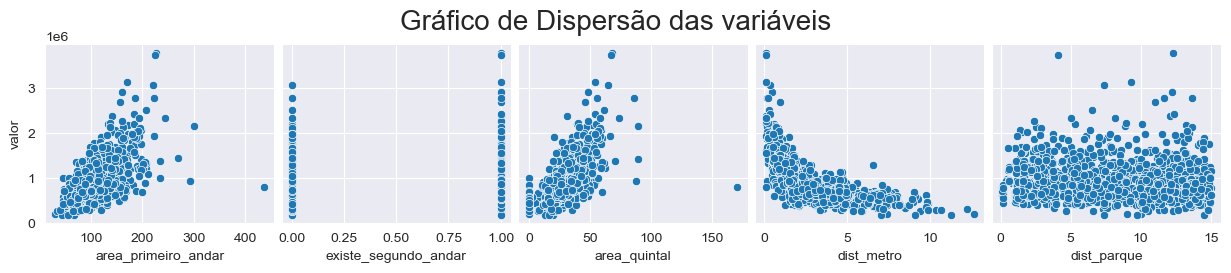

In [13]:
ax = sns.pairplot(data=dados, y_vars='valor', x_vars=lista_colunas_x.columns)
ax.figure.suptitle('Gráfico de Dispersão das variáveis', fontsize=20, y=1.05)
plt.show()

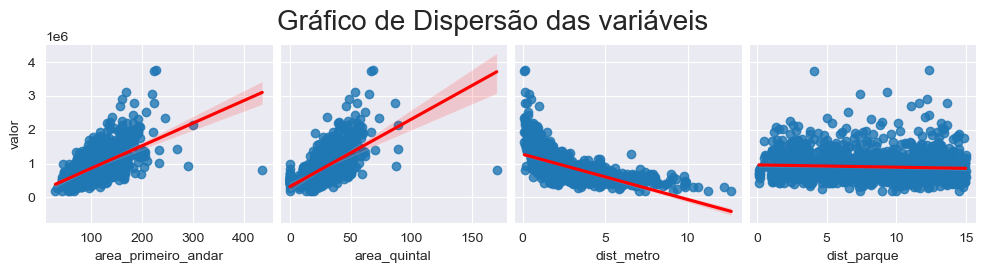

In [14]:
ax = sns.pairplot(data=dados, y_vars='valor', x_vars=['area_primeiro_andar', 'area_quintal',
       'dist_metro', 'dist_parque'], kind='reg', plot_kws={'line_kws':{'color':'red'}})
ax.figure.suptitle('Gráfico de Dispersão das variáveis', fontsize=20, y=1.05)
plt.show()

### Aplicando Transformação logarítima

###### Usaremos np.log() e np.log1p() nas variáveis, o np.log1p() soma um antes de fazer a transformação logarítima, caso haja um valor 0, pois log de 0 não está definido no conjunto dos números reais.

In [15]:
# verificando se há 0 nas variáveis explicativas
dados.describe().round(2)

,valor,area_primeiro_andar,existe_segundo_andar,area_quintal,dist_metro,dist_parque
count,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00
mean,904605.98,108.01,0.43,29.47,2.77,8.15
std,397212.51,35.92,0.50,12.23,1.91,4.20
min,174500.00,31.03,0.00,0.00,0.10,0.12
25%,649875.00,81.94,0.00,22.18,1.42,4.44
50%,815000.00,100.98,0.00,27.64,2.26,8.72
75%,1070000.00,129.25,1.00,36.18,3.89,11.63
max,3775000.00,435.90,1.00,170.29,12.65,15.00


In [16]:
dados.columns

Index(['valor', 'area_primeiro_andar', 'existe_segundo_andar', 'area_quintal',
       'dist_metro', 'dist_parque'],
      dtype='object')

In [17]:
import numpy as np

In [18]:
dados['log_valor'] = np.log(dados['valor'])
dados['log_area_primeiro_andar'] = np.log(dados['area_primeiro_andar'])
dados['log_area_quintal'] = np.log1p(dados['area_quintal'])
dados['log_dist_metro'] = np.log(dados['dist_metro'])
dados['log_dist_parque'] = np.log(dados['dist_parque'])

In [19]:
dados.head(3)

,valor,area_primeiro_andar,existe_segundo_andar,area_quintal,dist_metro,dist_parque,log_valor,log_area_primeiro_andar,log_area_quintal,log_dist_metro,log_dist_parque
0,1042500,79.52,1,23.86,1.639,3.039,13.857132,4.376009,3.213260,0.494086,1.111529
1,907500,117.24,0,35.17,1.538,10.910,13.718449,4.764223,3.588230,0.430483,2.389680
2,1117500,85.47,1,25.64,1.275,11.791,13.926605,4.448165,3.282414,0.242946,2.467337


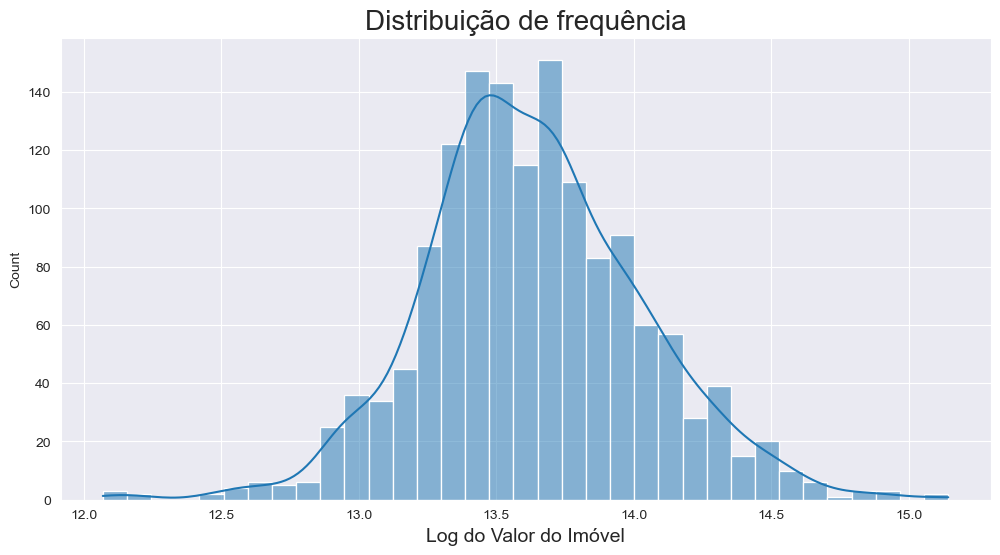

In [20]:
ax = sns.histplot(data=dados, x='log_valor', kde=True)
ax.figure.set_size_inches(12,6)
ax.set_title('Distribuição de frequência', fontsize=20)
ax.set_xlabel('Log do Valor do Imóvel', fontsize=14)
plt.show()

### Verificando a relação linear

In [21]:
dados.columns

Index(['valor', 'area_primeiro_andar', 'existe_segundo_andar', 'area_quintal',
       'dist_metro', 'dist_parque', 'log_valor', 'log_area_primeiro_andar',
       'log_area_quintal', 'log_dist_metro', 'log_dist_parque'],
      dtype='object')

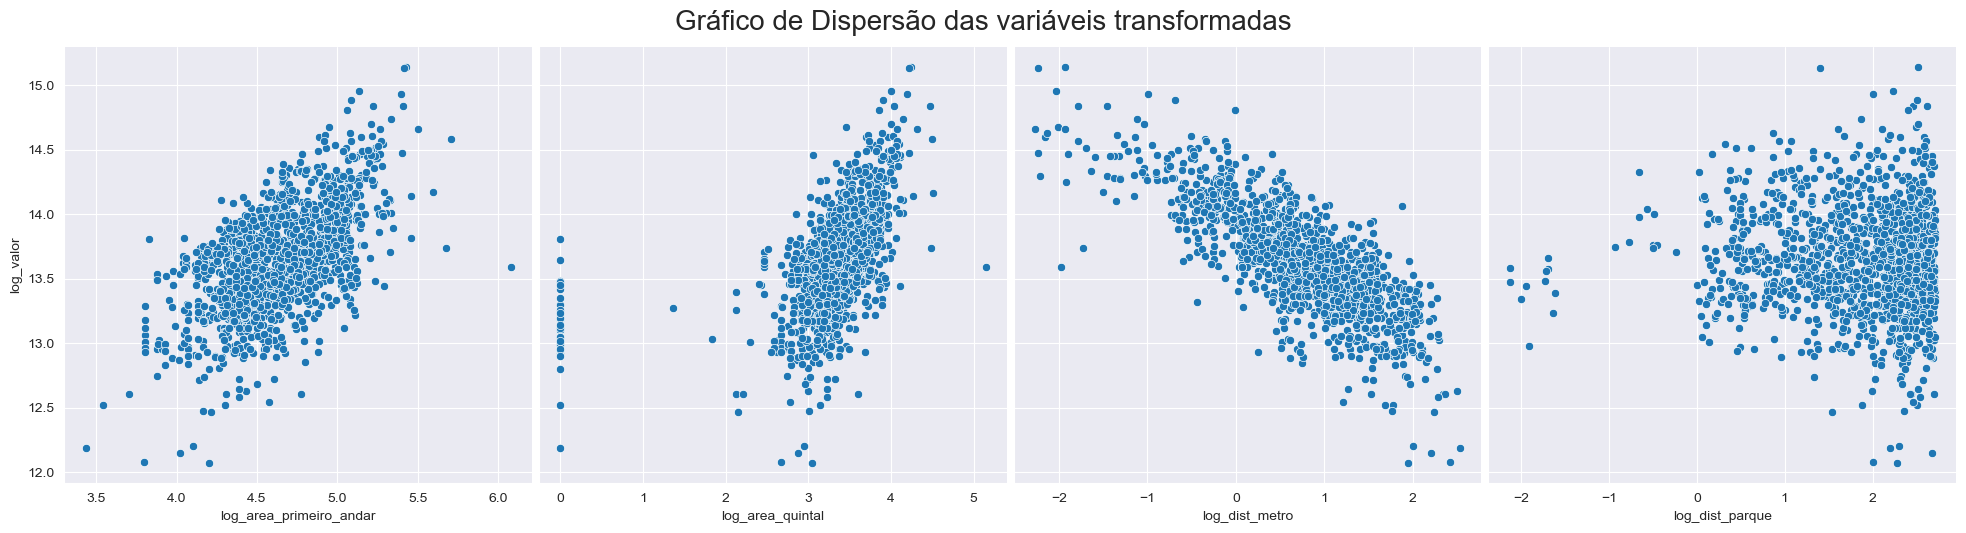

In [22]:
ax = sns.pairplot(data=dados, y_vars='log_valor', x_vars=['log_area_primeiro_andar',
       'log_area_quintal', 'log_dist_metro', 'log_dist_parque'], height=5)
ax.figure.suptitle('Gráfico de Dispersão das variáveis transformadas', fontsize=20, y=1.05)
plt.show()

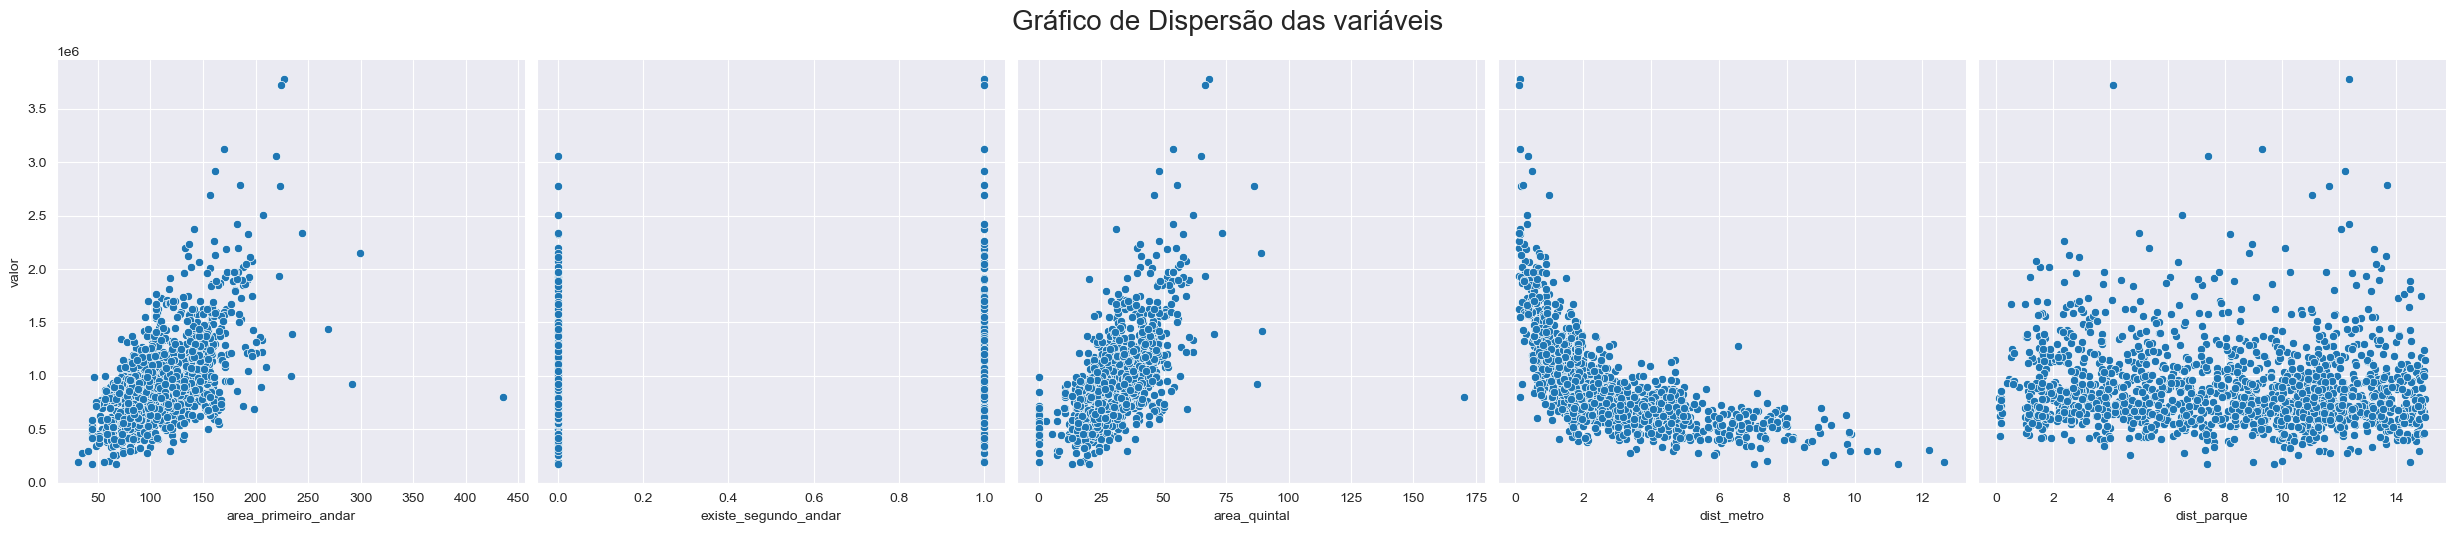

In [23]:
ax = sns.pairplot(data=dados, y_vars='valor', x_vars=lista_colunas_x.columns, height=5)
ax.figure.suptitle('Gráfico de Dispersão das variáveis', fontsize=20, y=1.05)
plt.show()

### Preparando os dados

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
y = dados['log_valor']
x = dados[['log_area_primeiro_andar', 'existe_segundo_andar',
       'log_area_quintal', 'log_dist_metro', 'log_dist_parque']]

In [26]:
help(train_test_split)

Help on function train_test_split in module sklearn.model_selection._split:

train_test_split(
    *arrays,
    test_size=None,
    train_size=None,
    random_state=None,
    shuffle=True,
    stratify=None
)
    Split arrays or matrices into random train and test subsets.

    Quick utility that wraps input validation,
    ``next(ShuffleSplit().split(X, y))``, and application to input data
    into a single call for splitting (and optionally subsampling) data into a
    one-liner.

    Read more in the :ref:`User Guide <cross_validation>`.

    Parameters
    ----------
    *arrays : sequence of indexables with same length / shape[0]
        Allowed inputs are lists, numpy arrays, scipy-sparse
        matrices or pandas dataframes.

    test_size : float or int, default=None
        If float, should be between 0.0 and 1.0 and represent the proportion
        of the dataset to include in the test split. If int, represents the
        absolute number of test samples. If None, the value

In [27]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1991)

In [28]:
X_train

,log_area_primeiro_andar,existe_segundo_andar,log_area_quintal,log_dist_metro,log_dist_parque
480,5.146738,0,3.952973,-1.158362,1.092930
175,5.300714,0,3.540959,0.579978,2.571467
891,4.445940,1,3.280535,0.758935,2.424537
101,4.508329,1,3.075005,0.948177,0.506215
403,4.684259,1,3.490429,-0.050241,1.863770
...,...,...,...,...,...
519,4.775250,1,3.598955,0.431133,2.296768
397,4.399130,1,3.222071,1.425515,0.215111
1331,4.484470,0,3.272985,1.203273,1.000632
1102,4.657288,0,3.372455,1.310223,1.360977


In [29]:
X_test

,log_area_primeiro_andar,existe_segundo_andar,log_area_quintal,log_dist_metro,log_dist_parque
999,4.720550,0,3.528711,0.617885,0.521172
105,4.583231,1,3.412797,-0.198451,1.085189
864,4.847803,0,3.669697,0.044973,2.122022
1168,4.743453,1,3.478467,0.413433,1.893263
26,4.426163,0,3.261169,1.158452,2.521881
...,...,...,...,...,...
66,5.323205,0,4.012049,0.206201,-0.234457
1007,3.926517,1,2.786245,1.680083,2.305780
1132,4.695376,1,3.370394,0.698135,1.537297
88,4.544464,0,3.375196,2.101937,2.343535


### Avaliando as estatísticas do modelo com Statsmodels

In [30]:
import statsmodels.api as sm

In [31]:
X_train_const = sm.add_constant(X_train)

In [32]:
X_train_const.head()

,const,log_area_primeiro_andar,existe_segundo_andar,log_area_quintal,log_dist_metro,log_dist_parque
480,1.0,5.146738,0,3.952973,-1.158362,1.092930
175,1.0,5.300714,0,3.540959,0.579978,2.571467
891,1.0,4.445940,1,3.280535,0.758935,2.424537
101,1.0,4.508329,1,3.075005,0.948177,0.506215
403,1.0,4.684259,1,3.490429,-0.050241,1.863770


In [33]:
modelo_stastmodels = sm.OLS(y_train, X_train_const, hasconst=True).fit()
modelo_stastmodels.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_valor   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     641.1
Date:                Thu, 14 Aug 2025   Prob (F-statistic):          3.38e-311
Time:                        14:43:33   Log-Likelihood:                 214.53
No. Observations:                1022   AIC:                            -417.1
Df Residuals:                    1016   BIC:                            -387.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      11.1983      0.127     88.044      0.000      10.949      11.448
log_area_primeiro_andar     0.4983      0.026     18.955      0.000       0.447       0.550
existe_segundo_andar        0.1871      0.015     12.827      0.000       0.158       0.216
log_area_quintal            0.0793      0.011      7.134      0.000       0.057       0.101
log_dist_metro             -0.2607      0.010    -26.284      0.000      -0.280      -0.241
log_dist_parque            -0.0092      0.008     -1.149      0.251      -0.025       0.006
==============================================================================
Omnibus:                      424.287   Durbin-Watson:                   2.046
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3729.961
Skew:                          -1.668   Prob(JB):                         0.00
Kurtosis:                      11.744   Cond. No.                         130.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Treinando o modelo

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [35]:
# Atualizando as variáveis de entrada do modelo
X_train_novo = X_train.drop(columns = 'log_dist_parque')
X_test_novo = X_test.drop(columns = 'log_dist_parque')

In [36]:
X_train_novo

,log_area_primeiro_andar,existe_segundo_andar,log_area_quintal,log_dist_metro
480,5.146738,0,3.952973,-1.158362
175,5.300714,0,3.540959,0.579978
891,4.445940,1,3.280535,0.758935
101,4.508329,1,3.075005,0.948177
403,4.684259,1,3.490429,-0.050241
...,...,...,...,...
519,4.775250,1,3.598955,0.431133
397,4.399130,1,3.222071,1.425515
1331,4.484470,0,3.272985,1.203273
1102,4.657288,0,3.372455,1.310223


In [37]:
# Instanciando modelo
modelo = LinearRegression()

In [38]:
modelo.fit(X_train_novo, y_train)

LinearRegression()

### R2 dos dados de treino e da previsão

###### O R² (coeficiente de determinação) é uma métrica que mede o quanto do comportamento da variável dependente (y) é explicado pelo modelo.



In [39]:
print(f'R² = {modelo.score(X_train_novo, y_train):.3f}')

R² = 0.759


In [40]:
y_previsto = modelo.predict(X_test_novo)

In [41]:
print(f'R² = {metrics.r2_score(y_test, y_previsto):.3f}')

R² = 0.738


### Preficicando uma casa

In [42]:
modelo.feature_names_in_

array(['log_area_primeiro_andar', 'existe_segundo_andar',
       'log_area_quintal', 'log_dist_metro'], dtype=object)

In [43]:
nova_casa = pd.DataFrame({
    'log_area_primeiro_andar': [np.log(200)],
    'existe_segundo_andar': [0],
    'log_area_quintal':[np.log1p(100)],
    'log_dist_metro':[np.log1p(0.750)]
})

In [44]:
modelo.predict(nova_casa)[0]

np.float64(14.041739399375935)

In [45]:
print(f'R$ {np.exp(modelo.predict(nova_casa)[0]):,.2f}')

R$ 1,253,862.57


### Obtendo o Intercepto

##### O intercepto (ou intercept, também chamado de β₀) é o valor que o modelo de regressão prevê para Y quando todas as variáveis X são iguais a zero.

In [48]:
modelo.intercept_

np.float64(11.174572203750294)

In [66]:
print(f'{np.exp(modelo.intercept_):,.2f}')

71,294.34


##### Os coeficientes de regressão (também chamados de pesos ou β₁, β₂, β₃...) são os números que indicam quanto e em qual direção cada variável independente 𝑋 influencia a variável dependente 𝑌 no modelo de regressão.

##### Eles mostram quais variáveis mais influenciam a previsão.

##### Analisar magnitude e sinal dos coeficientes ajuda a entender a relação entre os fatores.

In [56]:
modelo.coef_

array([ 0.49955726,  0.1877953 ,  0.07936964, -0.26079708])

In [58]:
print(f'{np.exp(modelo.coef_[0]):,.5f}')

1.64799


### Construindo uma tabela com os coeficientes e seus valores

In [51]:
X_train_novo.columns

Index(['log_area_primeiro_andar', 'existe_segundo_andar', 'log_area_quintal',
       'log_dist_metro'],
      dtype='object')

In [52]:
index = ['Intercepto', 'log_area_primeiro_andar', 'existe_segundo_andar', 'log_area_quintal', 'log_dist_metro' ]

In [54]:
df_params = pd.DataFrame(data = np.append(modelo.intercept_, modelo.coef_), index = index, columns = ['Parâmetros'])
df_params.round(3)

,Parâmetros
Intercepto,11.175
log_area_primeiro_andar,0.500
existe_segundo_andar,0.188
log_area_quintal,0.079
log_dist_metro,-0.261


### Fórmula para conversão da variavel existe_segundo_andar (Binária)

##### Para achar o impacto percentual:

##### Impacto =(𝑒𝛽−1)×100

##### transforma de volta para a escala original.

##### Subtraímos 1 para obter apenas a variação.

##### Multiplicamos por 100 para percentual.

In [69]:
print(f'Efeito da variavel existe_segundo_andar {100 * np.expm1(df_params.loc['existe_segundo_andar'].iloc[0]):.2f} %')

Efeito da variavel existe_segundo_andar 20.66 %


### Analisando Graficamente os resultados do modelo

#### Analisando pelos dados de treino

In [73]:
y_train_previsto = modelo.predict(X_train_novo)

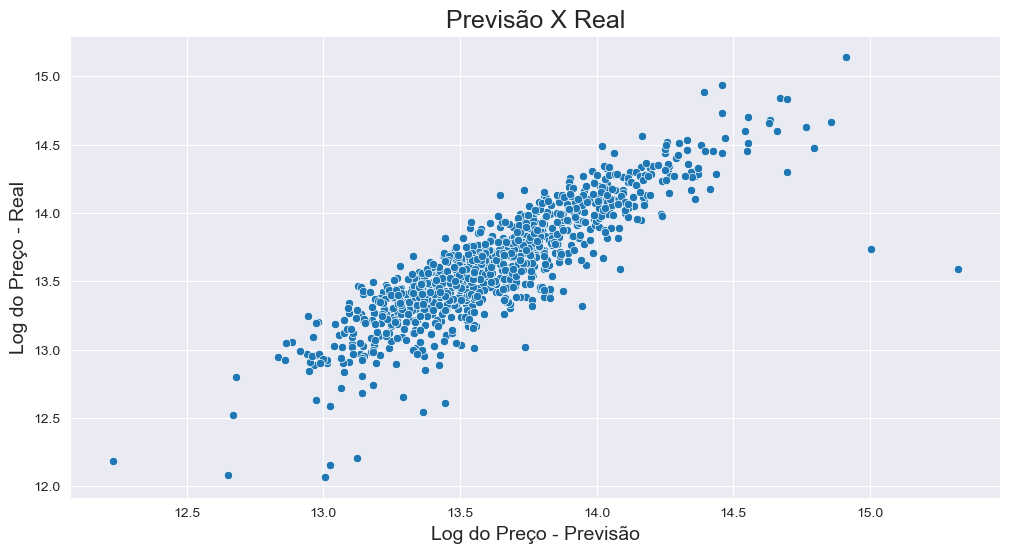

In [74]:
ax = sns.scatterplot(x = y_train_previsto, y = y_train)

ax.figure.set_size_inches(12,6)
ax.set_title('Previsão X Real', fontsize=18)
ax.set_xlabel('Log do Preço - Previsão', fontsize=14)
ax.set_ylabel('Log do Preço - Real', fontsize=14)
plt.show()

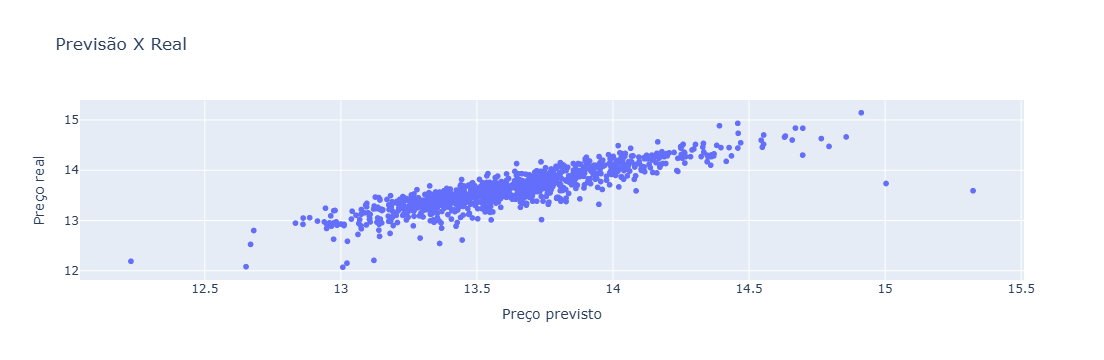

In [81]:
import plotly.express as px
fig = px.scatter(x=y_train_previsto, y=y_train, title="Previsão X Real", labels={'x': 'Preço previsto', 'y': 'Preço real'})
fig.show()

#### Obtendo os resíduos e observando seu comportamento

In [75]:
residuo = y_train - y_train_previsto

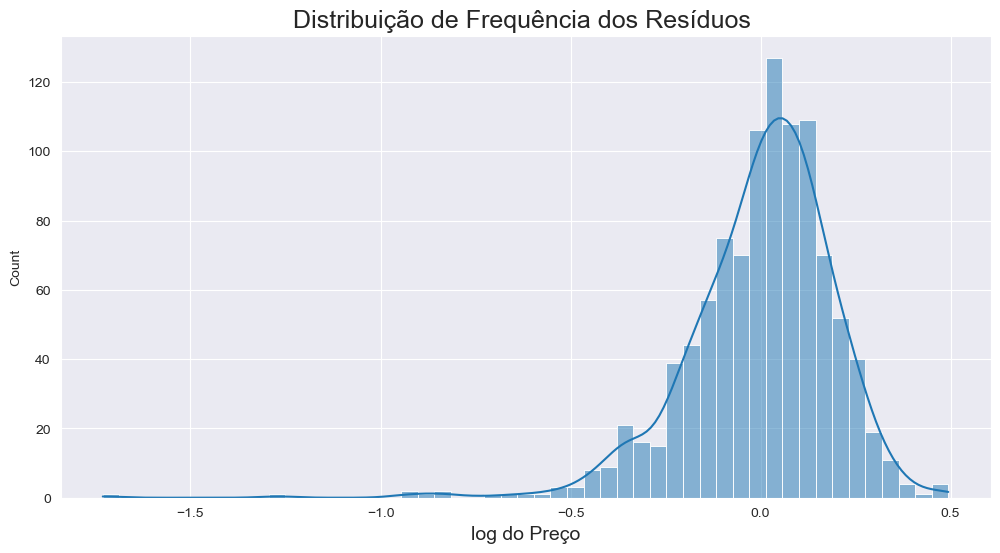

In [77]:
ax = sns.histplot(residuo, kde=True)

ax.figure.set_size_inches(12,6)
ax.set_title('Distribuição de Frequência dos Resíduos ', fontsize=18)
ax.set_xlabel('log do Preço', fontsize=14)
plt.show()

#### Homocedasticidade do modelo

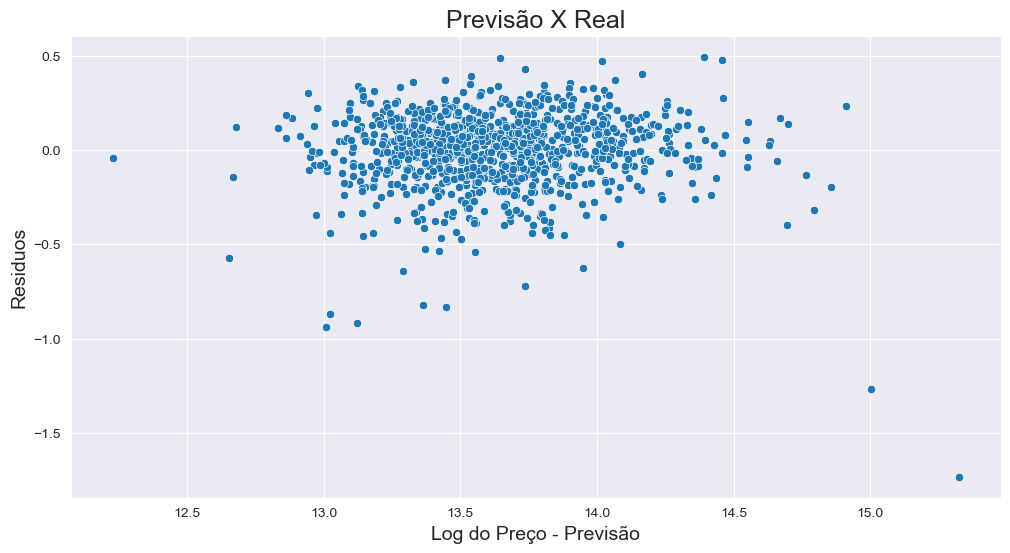

In [79]:
ax = sns.scatterplot(x = y_train_previsto, y = residuo)

ax.figure.set_size_inches(12,6)
ax.set_title('Previsão X Real', fontsize=18)
ax.set_xlabel('Log do Preço - Previsão', fontsize=14)
ax.set_ylabel('Residuos', fontsize=14)
plt.show()

### Salvando o modelo e prevendo mais casas

In [82]:
import pickle

In [83]:
arquivo = open('modelos_casa_a_preficicar.pkl', 'wb')
pickle.dump(modelo, arquivo)
arquivo.close()